# EDA

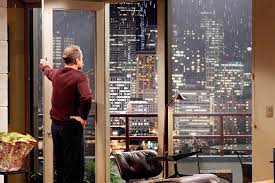

Hypotheses - Persona William Rodriguez (Buyer)

2 people, wants two houses: one in the country (best timing, non-renovated) and one in the city (fast, central location). Houses should be reasonably close to each other.

Country House
William isn't in a hurry, doesn't care about neighbors, needs a quiet place to unwind, and owns a dog. Space, privacy and price matter more than polish or central location.

H1 - Price vs renovation status

Non-renovated houses (yr_renovated = 0) are on average cheaper than renovated houses of comparable size and location.

Data: price, yr_renovated, sqft_living, zipcode

Test: compare the median price of non-renovated houses against renovated ones, keeping size and zip code roughly similar so the comparison is fair



In [27]:
import warnings

import matplotlib.pyplot as plt
import pandas as pd

warnings.filterwarnings("ignore")

plt.rcParams.update(
    {"figure.figsize": (8, 5), "axes.facecolor": "white", "axes.edgecolor": "black"}
)
plt.rcParams["figure.facecolor"] = "w"
pd.plotting.register_matplotlib_converters()
pd.set_option("display.float_format", lambda x: "%.3f" % x)

reconnect to database

In [29]:
import psycopg2
from dotenv import load_dotenv
import os

load_dotenv()

# Use the correct variable names from your .env file
conn = psycopg2.connect(
    database=os.getenv("DATABASE"),
    user=os.getenv("USER_DB"),
    password=os.getenv("PASSWORD"),
    host=os.getenv("HOST"),
    port=os.getenv("PORT")
)

print(" Database connection successful!")

 Database connection successful!


#Step 1: Explore the data — Check columns & basic info

In [30]:
# Query the full dataset
query_string = "SELECT * FROM eda.king_county_house_sales LIMIT 1"
df_sqlalchemy = pd.read_sql(query_string, conn)

print(f"Columns available: {df_sqlalchemy.columns.tolist()}")
print(f"Total columns: {len(df_sqlalchemy.columns)}")

Columns available: ['date', 'price', 'house_id', 'id']
Total columns: 4


In [31]:
import psycopg2
from psycopg2 import sql

cursor = conn.cursor()

# List all tables in the 'eda' schema
cursor.execute("""
    SELECT table_name 
    FROM information_schema.tables 
    WHERE table_schema = 'eda'
""")

tables = cursor.fetchall()
print("Tables in 'eda' schema:")
for table in tables:
    print(f"  - {table[0]}")

cursor.close()

Tables in 'eda' schema:
  - king_county_house_details
  - king_county_house_sales


In [32]:
cursor = conn.cursor()

cursor.execute("""
    SELECT column_name 
    FROM information_schema.columns 
    WHERE table_schema = 'eda' AND table_name = 'king_county_house_details'
    ORDER BY ordinal_position
""")

columns = cursor.fetchall()
print("Columns in king_county_house_details:")
for col in columns:
    print(f"  - {col[0]}")

cursor.close()

Columns in king_county_house_details:
  - id
  - bedrooms
  - bathrooms
  - sqft_living
  - sqft_lot
  - floors
  - waterfront
  - view
  - condition
  - grade
  - sqft_above
  - sqft_basement
  - yr_built
  - yr_renovated
  - zipcode
  - lat
  - long
  - sqft_living15
  - sqft_lot15





Join both tables

In [33]:
# Query: JOIN sales with details using the common key
query_string = """
SELECT 
    s.date,
    s.price,
    s.house_id,
    d.id,
    d.bedrooms,
    d.bathrooms,
    d.sqft_living,
    d.sqft_lot,
    d.floors,
    d.waterfront,
    d.view,
    d.condition,
    d.grade,
    d.sqft_above,
    d.sqft_basement,
    d.yr_built,
    d.yr_renovated,
    d.zipcode,
    d.lat,
    d.long,
    d.sqft_living15,
    d.sqft_lot15
FROM eda.king_county_house_sales s
JOIN eda.king_county_house_details d ON s.house_id = d.id
"""

df_sqlalchemy = pd.read_sql(query_string, conn)

print(" Full dataset loaded!")
print(f"Shape: {df_sqlalchemy.shape}")
print(f"\nColumns ({len(df_sqlalchemy.columns)}):")
print(df_sqlalchemy.columns.tolist())
print(f"\nFirst row:")
print(df_sqlalchemy.head(1))

 Full dataset loaded!
Shape: (21597, 22)

Columns (22):
['date', 'price', 'house_id', 'id', 'bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot', 'floors', 'waterfront', 'view', 'condition', 'grade', 'sqft_above', 'sqft_basement', 'yr_built', 'yr_renovated', 'zipcode', 'lat', 'long', 'sqft_living15', 'sqft_lot15']

First row:
         date      price    house_id          id  bedrooms  bathrooms  \
0  2014-10-13 221900.000  7129300520  7129300520     3.000      1.000   

   sqft_living  sqft_lot  floors  waterfront  ...  grade  sqft_above  \
0     1180.000  5650.000   1.000         NaN  ...      7    1180.000   

   sqft_basement  yr_built  yr_renovated  zipcode    lat     long  \
0          0.000      1955         0.000    98178 47.511 -122.257   

   sqft_living15  sqft_lot15  
0       1340.000    5650.000  

[1 rows x 22 columns]


In [75]:
# Basic count of unique zipcodes
num_zipcodes = df_h1_final['zipcode'].nunique()
print(f"Total number of unique zipcodes: {num_zipcodes}")

# See all zipcodes and how many houses are in each
zipcode_counts = df_h1_final['zipcode'].value_counts().sort_index()
print("\nHouses per zipcode:")
print(zipcode_counts)

# Summary statistics about zipcode distribution
print(f"\nZipcode with most houses: {zipcode_counts.idxmax()} ({zipcode_counts.max()} houses)")
print(f"Zipcode with fewest houses: {zipcode_counts.idxmin()} ({zipcode_counts.min()} houses)")
print(f"Average houses per zipcode: {zipcode_counts.mean():.0f}")

# Identify your rural zipcodes in the data
rural_zipcodes = [98038, 98042, 98023]
rural_present = [z for z in rural_zipcodes if z in df_h1_final['zipcode'].values]
print(f"\nRural zipcodes in dataset: {rural_present}")

# Count how many houses in rural vs urban
df_h1_final['location_type'] = df_h1_final['zipcode'].apply(
    lambda x: 'Rural' if x in rural_zipcodes else 'Urban'
)
location_counts = df_h1_final['location_type'].value_counts()
print(f"\nUrban vs Rural breakdown:")
print(location_counts)

Total number of unique zipcodes: 70

Houses per zipcode:
zipcode
98001    361
98002    199
98003    280
98004    154
98005    152
        ... 
98177    231
98178    261
98188    136
98198    278
98199    273
Name: count, Length: 70, dtype: int64

Zipcode with most houses: 98103 (588 houses)
Zipcode with fewest houses: 98039 (6 houses)
Average houses per zipcode: 292

Rural zipcodes in dataset: [98038, 98042, 98023]

Urban vs Rural breakdown:
location_type
Urban    18809
Rural     1630
Name: count, dtype: int64


In [63]:
# List all zipcodes with house counts
all_zipcodes = sorted(df_h1_final['zipcode'].unique())
print("All zipcodes in the dataset:\n")
for zipcode in all_zipcodes:
    count = len(df_h1_final[df_h1_final['zipcode'] == zipcode])
    print(f"Zipcode {zipcode}: {count} houses")

All zipcodes in the dataset:

Zipcode 98001: 361 houses
Zipcode 98002: 199 houses
Zipcode 98003: 280 houses
Zipcode 98004: 154 houses
Zipcode 98005: 152 houses
Zipcode 98006: 403 houses
Zipcode 98007: 137 houses
Zipcode 98008: 266 houses
Zipcode 98010: 100 houses
Zipcode 98011: 195 houses
Zipcode 98014: 121 houses
Zipcode 98019: 190 houses
Zipcode 98022: 233 houses
Zipcode 98023: 497 houses
Zipcode 98024: 73 houses
Zipcode 98027: 394 houses
Zipcode 98028: 281 houses
Zipcode 98029: 313 houses
Zipcode 98030: 256 houses
Zipcode 98031: 273 houses
Zipcode 98032: 125 houses
Zipcode 98033: 367 houses
Zipcode 98034: 526 houses
Zipcode 98038: 586 houses
Zipcode 98039: 6 houses
Zipcode 98040: 165 houses
Zipcode 98042: 547 houses
Zipcode 98045: 218 houses
Zipcode 98052: 563 houses
Zipcode 98053: 379 houses
Zipcode 98055: 268 houses
Zipcode 98056: 403 houses
Zipcode 98058: 453 houses
Zipcode 98059: 452 houses
Zipcode 98065: 303 houses
Zipcode 98070: 115 houses
Zipcode 98072: 265 houses
Zipcode 980

add new collumn as location, consider variables rural for following zip codes (price': 'mean',
    'sqft_lot': 'mean',
    'floors': 'mean',
    'zipcode': 'count),
     the rest of zip codes will have the variable urban

In [65]:
import numpy as np

zipcode_stats = df_h1_final.groupby('zipcode').agg({
    'price': 'mean',
    'sqft_lot': 'mean',
    'floors': 'mean',
    'zipcode': 'count'
}).rename(columns={'zipcode': 'house_count'})

# Normalize manually (0-1 scale)
def normalize(series):
    return (series - series.min()) / (series.max() - series.min())

zipcode_stats['price_normalized'] = normalize(zipcode_stats['price'])
zipcode_stats['lot_normalized'] = normalize(zipcode_stats['sqft_lot'])
zipcode_stats['floors_normalized'] = normalize(zipcode_stats['floors'])

zipcode_stats['urban_score'] = (
    zipcode_stats['price_normalized'] * 0.4 +
    (1 - zipcode_stats['lot_normalized']) * 0.3 +
    zipcode_stats['floors_normalized'] * 0.3
)

zipcode_stats['classification'] = zipcode_stats['urban_score'].apply(
    lambda x: 'Urban' if x >= 0.5 else 'Rural'
)

print("Zipcode Classification:")
print(zipcode_stats[['price', 'sqft_lot', 'floors', 'urban_score', 'classification']].sort_values('urban_score', ascending=False))

rural_zipcodes_all = zipcode_stats[zipcode_stats['classification'] == 'Rural'].index.tolist()
urban_zipcodes_all = zipcode_stats[zipcode_stats['classification'] == 'Urban'].index.tolist()

print(f"\nRural zipcodes ({len(rural_zipcodes_all)}): {sorted(rural_zipcodes_all)}")
print(f"Urban zipcodes ({len(urban_zipcodes_all)}): {sorted(urban_zipcodes_all)}")

Zipcode Classification:
             price  sqft_lot  floors  urban_score classification
zipcode                                                         
98102   696013.614  2921.534   1.949        0.877          Urban
98112   728852.054  3753.940   1.695        0.814          Urban
98119   695016.503  3315.686   1.729        0.806          Urban
98075   730011.391 17571.321   1.797        0.803          Urban
98029   589195.907  6800.853   1.949        0.801          Urban
...            ...       ...     ...          ...            ...
98168   240328.372 11269.844   1.160        0.328          Rural
98024   486844.795 84140.658   1.356        0.305          Rural
98014   426500.182 90361.760   1.483        0.290          Rural
98070   474153.878 97048.191   1.417        0.276          Rural
98022   316742.391 74233.914   1.324        0.225          Rural

[70 rows x 5 columns]

Rural zipcodes (28): [98001, 98002, 98003, 98010, 98014, 98022, 98023, 98024, 98030, 98031, 98032, 98042, 9

Explore data to clean if needed

In [69]:
# Query the joined dataset
query_string = """
SELECT 
    s.date, s.price, s.house_id,
    d.id, d.bedrooms, d.bathrooms, d.sqft_living, d.sqft_lot, d.floors,
    d.waterfront, d.view, d.condition, d.grade, d.sqft_above, d.sqft_basement,
    d.yr_built, d.yr_renovated, d.zipcode, d.lat, d.long,
    d.sqft_living15, d.sqft_lot15
FROM eda.king_county_house_sales s
JOIN eda.king_county_house_details d ON s.house_id = d.id
"""

df_sqlalchemy = pd.read_sql(query_string, conn)
print(f" Dataset loaded: {df_sqlalchemy.shape}")

 Dataset loaded: (21597, 22)


Size Range Information:
                min      max
size_range                  
Small       650.000 1670.000
Medium     1677.000 2260.000
Large      2270.000 5820.000


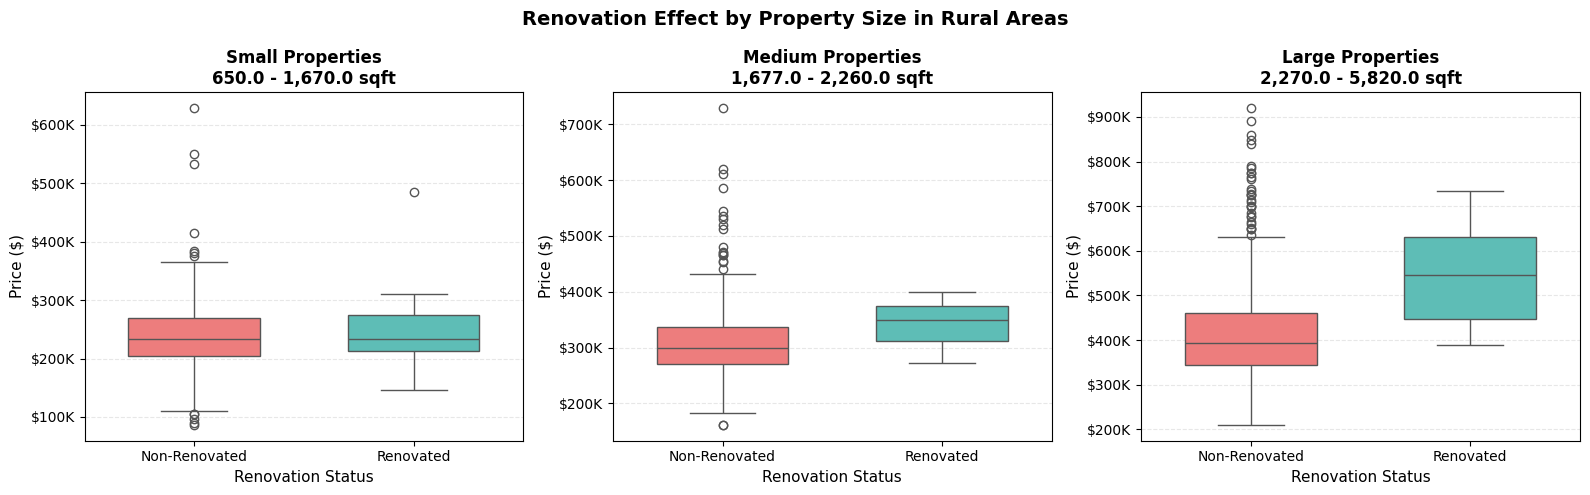

In [71]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Filter for rural properties only
df_rural = df_h1_final[df_h1_final['location_type'] == 'Rural'].copy()

# Create 3 size ranges using tertiles
df_rural['size_range'] = pd.qcut(df_rural['sqft_living'], q=3, labels=['Small', 'Medium', 'Large'])

# Get the actual sqft ranges for labeling
size_ranges_info = df_rural.groupby('size_range')['sqft_living'].agg(['min', 'max'])
print("Size Range Information:")
print(size_ranges_info)

# Create figure with 3 subplots
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Renovation Effect by Property Size in Rural Areas', fontsize=14, fontweight='bold')

size_categories = ['Small', 'Medium', 'Large']
colors = ['#FF6B6B', '#4ECDC4']

for idx, size_cat in enumerate(size_categories):
    df_size = df_rural[df_rural['size_range'] == size_cat]
    
    # Get sqft range for this category
    min_sqft = df_size['sqft_living'].min()
    max_sqft = df_size['sqft_living'].max()
    
    # Create box plot
    sns.boxplot(
        data=df_size,
        x='renovation_status',
        y='price',
        ax=axes[idx],
        palette=colors,
        width=0.6
    )
    
    # Set title with actual sqft range
    title = f'{size_cat} Properties\n{min_sqft:,} - {max_sqft:,} sqft'
    axes[idx].set_title(title, fontweight='bold', fontsize=12)
    axes[idx].set_xlabel('Renovation Status', fontsize=11)
    axes[idx].set_ylabel('Price ($)', fontsize=11)
    axes[idx].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x/1000:.0f}K'))
    axes[idx].grid(axis='y', alpha=0.3, linestyle='--')

plt.tight_layout()
plt.show()

Specific offers for the buyers based on hypothesis 1

In [74]:
# Filter for rural, non-renovated, medium size
df_candidates = df_rural[
    (df_rural['renovation_status'] == 'Non-Renovated') &
    (df_rural['size_range'] == 'Medium')
].copy()

# Sort by price (lowest first to show best value)
df_candidates = df_candidates.sort_values('price')

# Select top 2 houses
selected_houses = df_candidates.head(2)

# Display details
print("Two Non-Renovated Medium-Size Rural Properties:\n")
for idx, (i, row) in enumerate(selected_houses.iterrows(), 1):
    print(f"Property {idx}:")
    print(f"  Zipcode: {row['zipcode']}")
    print(f"  Price: ${row['price']:,.0f}")
    print(f"  Sqft Living: {row['sqft_living']:,}")
    print(f"  Bedrooms: {row['bedrooms']}")
    print(f"  Bathrooms: {row['bathrooms']}")
    print(f"  Year Built: {row['yr_built']}")
    print(f"  Lot Size: {row['sqft_lot']:,}")

Two Non-Renovated Medium-Size Rural Properties:

Property 1:
  Zipcode: 98023
  Price: $161,700
  Sqft Living: 1,720.0
  Bedrooms: 4.0
  Bathrooms: 1.75
  Year Built: 1974
  Lot Size: 7,200.0
Property 2:
  Zipcode: 98023
  Price: $162,000
  Sqft Living: 1,810.0
  Bedrooms: 3.0
  Bathrooms: 2.25
  Year Built: 1978
  Lot Size: 6,750.0


In [76]:
# Save as CSV (recommended - easy to inspect and share)
df_h1_final.to_csv('df_h1_final_cleaned.csv', index=False)
print("Saved: df_h1_final_cleaned.csv")

# Optional: Also save as pickle (preserves exact data types)
import pickle
with open('df_h1_final_cleaned.pkl', 'wb') as f:
    pickle.dump(df_h1_final, f)
print("Saved: df_h1_final_cleaned.pkl")

Saved: df_h1_final_cleaned.csv
Saved: df_h1_final_cleaned.pkl


In [77]:
import pandas as pd

df_h1_final = pd.read_csv('df_h1_final_cleaned.csv')

print(f"Data loaded: {len(df_h1_final)} rows")
print(f"Columns: {df_h1_final.columns.tolist()}")
print(df_h1_final.head())

Data loaded: 20439 rows
Columns: ['date', 'price', 'house_id', 'id', 'bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot', 'floors', 'waterfront', 'view', 'condition', 'grade', 'sqft_above', 'sqft_basement', 'yr_built', 'yr_renovated', 'zipcode', 'lat', 'long', 'sqft_living15', 'sqft_lot15', 'renovation_status', 'location_type']
         date      price    house_id          id  bedrooms  bathrooms  \
0  2014-10-13 221900.000  7129300520  7129300520     3.000      1.000   
1  2014-12-09 538000.000  6414100192  6414100192     3.000      2.250   
2  2015-02-25 180000.000  5631500400  5631500400     2.000      1.000   
3  2014-12-09 604000.000  2487200875  2487200875     4.000      3.000   
4  2015-02-18 510000.000  1954400510  1954400510     3.000      2.000   

   sqft_living  sqft_lot  floors  waterfront  ...  sqft_basement  yr_built  \
0     1180.000  5650.000   1.000         NaN  ...          0.000      1955   
1     2570.000  7242.000   2.000       0.000  ...        400.000      1951  

In [78]:
# Save to CSV
df_h1_final.to_csv('df_h1_final_cleaned.csv', index=False)
print("File saved successfully!")

File saved successfully!


In [79]:
import os
print(os.listdir('.'))  # List files in current directory

['hypotheses_william_rodriguez.md', '04a_H2_eda.ipynb', 'hypothesis-1.md', 'LICENSE', 'uv.lock', 'df_h1_final_cleaned.pkl', 'pyproject.toml', '01_assignment.md', '02_workflow.md', 'README.md', 'column_names.md', 'hypotheses_william_rodriguez_v2.md', '03_fetching_the_data_eda.ipynb', '04_eda.ipynb', '.gitignore', '.env', '.venv', '.python-version', '.env.example', '.git', '04a_H1_eda.ipynb', 'data', '04_eda|_playground_data_cleaning copy.ipynb', 'df_h1_final_cleaned.csv']
